# ILC Convergence Analysis

Runs the five-bar sim through iterative learning control (ILC) on a circular trajectory, trial by trial, and inspects convergence.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import mujoco

from test import circle_trajectory
from src import ILC
from src.utils import u2theta, theta2u, read_state

## Load model + desired trajectory

In [2]:
model = mujoco.MjModel.from_xml_path("../five_bar.xml")
data = mujoco.MjData(model)

desired = np.array(circle_trajectory())
print("trajectory shape:", desired.shape)

trajectory shape: (63985, 2)


## Single-trial sim step

Feeds one commanded joint trajectory through the model from the `init` keyframe, returns actual joint trajectory.

In [3]:
def run_trial(model, data, u_cmd):
    mujoco.mj_resetDataKeyframe(model, data, 0)
    T = len(u_cmd)
    actual = np.zeros((T, 2))
    for t in range(T):
        data.ctrl[:] = u2theta(u_cmd[t])
        mujoco.mj_step(model, data)
        actual[t] = theta2u(read_state(model, data))
    return actual

## Trial 0 (open-loop, no learning yet)

Feed the desired joint trajectory directly as command, see how far off actual tracking is before ILC corrects anything.

open-loop error norm: 61.254


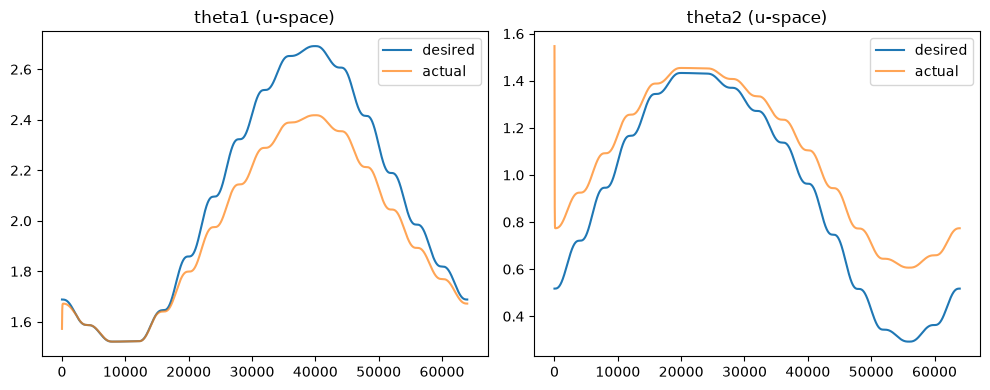

In [4]:
actual0 = run_trial(model, data, desired)
err0 = np.linalg.norm(desired - actual0)
print(f"open-loop error norm: {err0:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(desired[:, 0], label="desired")
axs[0].plot(actual0[:, 0], label="actual", alpha=0.7)
axs[0].set_title("theta1 (u-space)")
axs[0].legend()
axs[1].plot(desired[:, 1], label="desired")
axs[1].plot(actual0[:, 1], label="actual", alpha=0.7)
axs[1].set_title("theta2 (u-space)")
axs[1].legend()
plt.tight_layout()

## ILC loop

Fixed gain 0.2 (no search — tune only if divergence shows up).

In [5]:
TRIALS = 50

u = desired.copy()
controller = ILC(u, gain=0.2)

errs = []
trial_snapshots = {}

for i in range(TRIALS):
    actual = run_trial(model, data, u)
    errs.append(np.linalg.norm(desired - actual))
    if i in (0, 4, 9, TRIALS - 1):
        trial_snapshots[i] = actual.copy()
    controller.step(actual, desired)
    u = controller.u
    print(f"trial {i+1:2d} : error norm -> {errs[-1]:.4f}")

assert not np.isnan(errs[-1]), "diverged/nan"

trial  1 : error norm -> 61.2535


trial  2 : error norm -> 52.1632


trial  3 : error norm -> 44.4255


trial  4 : error norm -> 37.8407


trial  5 : error norm -> 32.2376


...

trial 46 : error norm -> 2.4813


trial 47 : error norm -> 2.4854


trial 48 : error norm -> 2.4895


trial 49 : error norm -> 2.4939


trial 50 : error norm -> 2.4985


## Convergence plot

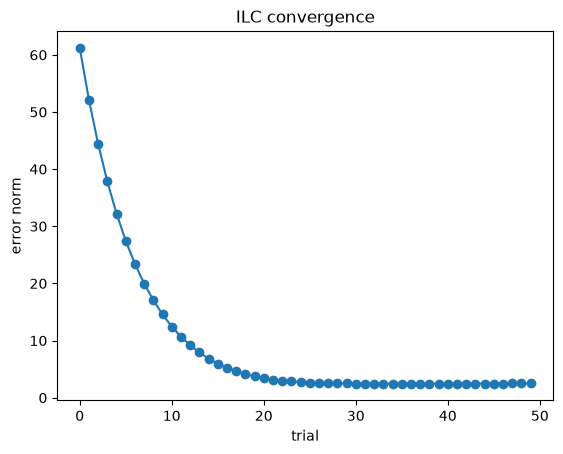

In [6]:
plt.plot(errs, marker="o")
plt.xlabel("trial")
plt.ylabel("error norm")
plt.title("ILC convergence")
plt.savefig("convergence_plot.png")
plt.show()

## Tracking improvement across trials

theta1 tracking at trial 1, 5, 10, and final trial vs desired.

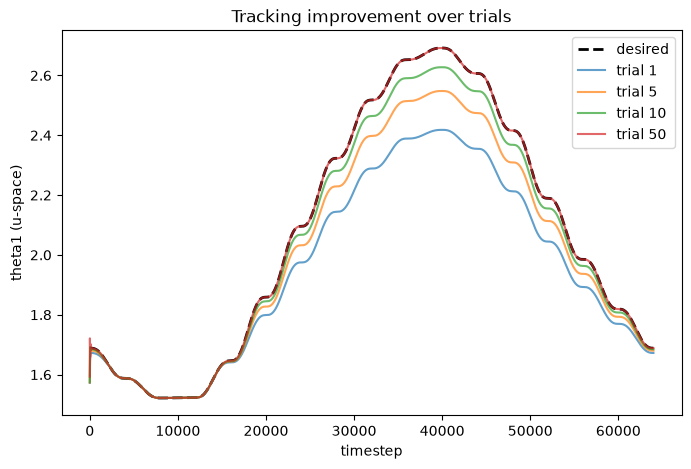

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(desired[:, 0], "k--", label="desired", linewidth=2)
for i, snap in trial_snapshots.items():
    plt.plot(snap[:, 0], label=f"trial {i+1}", alpha=0.7)
plt.xlabel("timestep")
plt.ylabel("theta1 (u-space)")
plt.title("Tracking improvement over trials")
plt.legend()

## Final trial workspace trajectory (via forward kinematics)

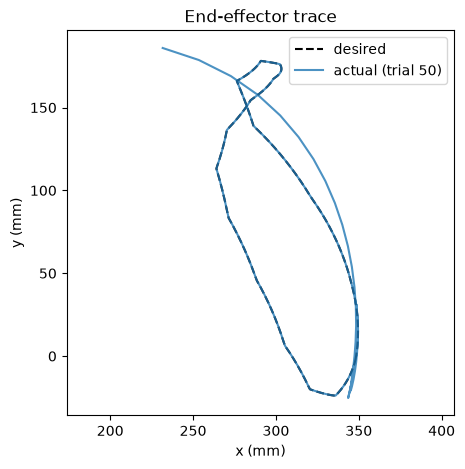

In [8]:
from src.utils import u2theta
from src import forward

final_actual = trial_snapshots[TRIALS - 1]
ee_desired = [forward(*u2theta(wp)) for wp in desired]
ee_actual = [forward(*u2theta(wp)) for wp in final_actual]

# forward() returns two IK branch solutions; pick branch closest to previous point
def pick_branch(sols, prev):
    if prev is None:
        return sols[0]
    return min(sols, key=lambda p: (p[0]-prev[0])**2 + (p[1]-prev[1])**2)

def trace(sols_list):
    pts, prev = [], None
    for sols in sols_list:
        if sols is None:
            continue
        p = pick_branch(sols, prev)
        pts.append(p)
        prev = p
    return np.array(pts)

d_pts = trace(ee_desired)
a_pts = trace(ee_actual)

plt.figure(figsize=(5, 5))
plt.plot(d_pts[:, 0], d_pts[:, 1], "k--", label="desired")
plt.plot(a_pts[:, 0], a_pts[:, 1], label=f"actual (trial {TRIALS})", alpha=0.8)
plt.axis("equal")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("End-effector trace")
plt.legend()